In [2]:
import pandas as pd
import numpy as np
results = pd.read_csv('results.csv', sep='\t')
results = results.dropna(subset=['User'])
results.sort_values(by=['User', 'System', 'Query'], inplace=True)
results['Score'] = pd.to_numeric(results['Score'], downcast='float', errors='coerce')
results["Time to correct"] = pd.to_numeric(results["Time to correct"], downcast='float', errors='coerce')

# # Ignoring wrong submissions
results["Score No Penalty"] = results["Time to correct"].apply(lambda x: 100 - 50 * x / 180 if x else 0)
results["Score No Penalty"].fillna(0, inplace=True)
# results.loc[results["Time to correct"].isna(), "Time to correct"] = 300
results["Hints"] = results["Time to correct"].transform(lambda x: min(x//30, 5))
import pandas as pd; import numpy as np
# Step: Change data type of Score to Float
results['Score'] = pd.to_numeric(results['Score'], downcast='float', errors='coerce')
import pandas as pd; import numpy as np
# Step: Change data type of User to Integer
results['User'] = pd.to_numeric(results['User'], downcast='integer', errors='coerce')

# Step: Create new column 'Solved' from formula 'Score > 0'
results['Solved'] = results['Score'] > 0

# Change system names from A, B to Baseline and QA
results['System'] = results['System'].replace({'A': 'Baseline', 'B': 'QA'})

In [21]:
results

,User,Query,Type,Wrong submissions,Time to correct,Score,System,Score No Penalty,Hints,Solved,First System
0,1,LSC20-52-5,Location,1.0,NaN,0.000000,Baseline,0.000000,NaN,False,Baseline
6,1,LSC20-58-2,Color,0.0,27.799000,92.279999,Baseline,92.278056,0.0,True,Baseline
2,1,LSC20-58-3,Counting,0.0,52.587002,85.389999,Baseline,85.392499,1.0,True,Baseline
3,1,LSC20-67-1,Date,1.0,65.019997,71.940002,Baseline,81.938890,2.0,True,Baseline
7,1,LSC20-67-2,Duration,0.0,63.127998,82.459999,Baseline,82.464445,2.0,True,Baseline
...,...,...,...,...,...,...,...,...,...,...,...
145,10,LSC21-78-4,Location,0.0,43.235001,87.989998,QA,87.990278,1.0,True,Baseline
146,10,LSC22-109-3,Counting,0.0,65.362999,81.839996,QA,81.843611,2.0,True,Baseline
148,10,LSC22-121-3,Object,0.0,145.783997,59.500000,QA,59.504445,4.0,True,Baseline
150,10,LSC23-QA10-1,Frequency,0.0,112.068001,68.870003,QA,68.870000,3.0,True,Baseline


In [28]:
# conduct significance test to compare the two systems
import scipy.stats as stats

# H0: The two systems have the same performance
# H1: The two systems have different performance

# We will use the Wilcoxon signed-rank test to compare the two systems
# because the data is not normally distributed
# and the two systems are dependent (i.e., the same users are using both systems)

# We will use the score as the dependent variable
# and the system as the independent variable
# and the user as the dependent variable

# Code here
field = "Score"

# Do it for each users
system1_scores = results[(results["System"] == "QA") & (results["First System"] == "QA")][field]
system2_scores = results[(results["System"] == "Baseline") & (results["First System"] == "Baseline")][field]

# Calculate means
mean1 = np.mean(system1_scores)
mean2 = np.mean(system2_scores)
print(f"Mean of system 1 is {mean1:.2f}")
print(f"Mean of system 2 is {mean2:.2f}")

# Calculate standard deviations
std1 = np.std(system1_scores)
std2 = np.std(system2_scores)

# Calculate sample sizes
n1 = len(system1_scores)
n2 = len(system2_scores)

# Calculate the Z statistic
z = (mean1 - mean2) / np.sqrt(std1**2 / n1 + std2**2 / n2)

# Calculate the two-tailed p-value
p = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"User {user}")
print(f"Z statistic is {z:.2f}")
print(f"P-value is {p:.4f}")

Mean of system 1 is 71.55
Mean of system 2 is 61.80
User OCR
Z statistic is 1.47
P-value is 0.1415


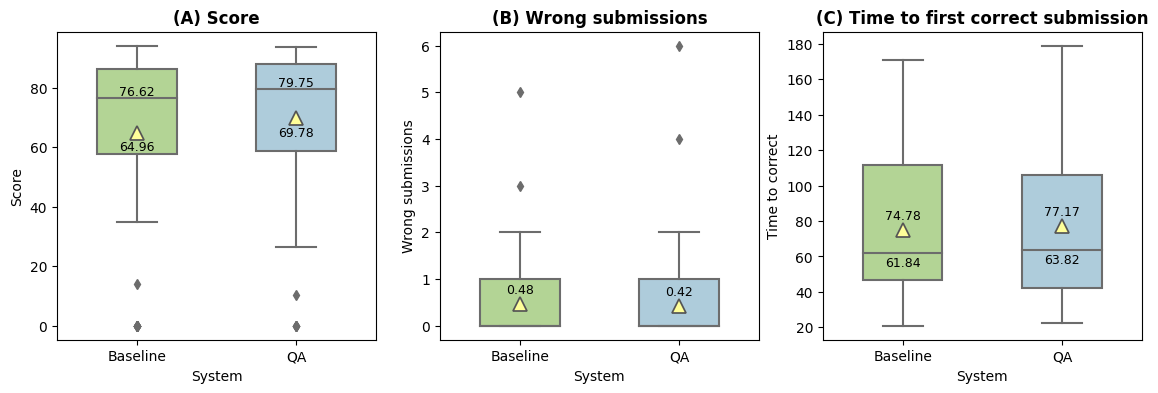

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
palette = ["#b2df8a", "#a6cee3", "#fdbf6f", "#ffff99"]
fig = plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
key = "Score"
# Plot 2 box plots for Score for each System with annotations for median and mean values
box_plot = sns.boxplot(y=key, x='System', data=results, 
            width=0.5, palette=palette, 
            showmeans=True, 
            meanprops={"markerfacecolor": palette[3], 
                       "markeredgecolor":"#555", 
                       "markersize":"10",
                       "markeredgewidth": 1.25},
            bootstrap=1000)
# # Annotations for median and mean values
medians = results.groupby(['System'])[key].median()
vertical_offset = results[key].median() * 0.01 # offset from median for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, medians[xtick] + vertical_offset,
                  round(medians[xtick], 2), 
                  horizontalalignment='center',
                  fontsize=9)
# # Annotations for median and mean values
means = results.groupby(['System'])[key].mean()
vertical_offset = - results[key].mean() * 0.09 # offset from mean for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, means[xtick] + vertical_offset,
                  round(means[xtick], 2), 
                  horizontalalignment='center',
                  fontsize=9)
box_plot.set_title("(A) Score", fontweight='bold')
plt.subplot(1, 3, 2)

key = "Wrong submissions"
box_plot = sns.boxplot(y=key, x='System', data=results, 
            width=0.5, palette=palette, 
            showmeans=True, 
            meanprops={"markerfacecolor": palette[3], 
                       "markeredgecolor":"#555", 
                       "markersize":"10",
                       "markeredgewidth": 1.25},
            bootstrap=1000)
# # Annotations for median and mean values
# medians = results.groupby(['System'])[key].median()
# vertical_offset = - results[key].median() * 0.08 # offset from median for display

# for xtick in box_plot.get_xticks():
#     box_plot.text(xtick, medians[xtick] + vertical_offset,
#                   round(medians[xtick], 2), 
#                   horizontalalignment='center')
# # Annotations for median and mean values
means = results.groupby(['System'])[key].mean()
vertical_offset = results[key].mean() * 0.5 # offset from mean for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, means[xtick] + vertical_offset,
                  round(means[xtick], 2), 
                  horizontalalignment='center',
                  fontsize=9)
    
box_plot.set_title("(B) Wrong submissions", fontweight='bold')
plt.subplot(1, 3, 3)
key = "Time to correct"
box_plot = sns.boxplot(y=key, x='System', data=results, 
            width=0.5, palette=palette, 
            showmeans=True, 
            meanprops={"markerfacecolor": palette[3], 
                       "markeredgecolor":"#555", 
                       "markersize":"10",
                       "markeredgewidth": 1.25},
            bootstrap=1000)
# # Annotations for median and mean values
medians = results.groupby(['System'])[key].median()
vertical_offset = - results[key].median() * 0.12 # offset from median for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, medians[xtick] + vertical_offset,
                  round(medians[xtick], 2), 
                  horizontalalignment='center',
                  fontsize=9)
# # Annotations for median and mean values
means = results.groupby(['System'])[key].mean()
vertical_offset = results[key].mean() * 0.08 # offset from mean for display

for xtick in box_plot.get_xticks():
    box_plot.text(xtick, means[xtick] + vertical_offset,
                  round(means[xtick], 2), 
                  horizontalalignment='center',
                  fontsize=9)
box_plot.set_title("(C) Time to first correct submission", fontweight='bold')
plt.savefig('overall_score.png', dpi=300, bbox_inches='tight')

In [9]:
# Add an "ALL" User to the results
all_results = results.groupby(["Query", "System"]).mean().reset_index()
all_results["User"] = "MEAN per Query"
results_with_means_users = pd.concat([results, all_results], ignore_index=True)

/tmp/ipykernel_1349728/139388335.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  all_results = results.groupby(["Query", "System"]).mean().reset_index()


/tmp/ipykernel_1349728/707166448.py:9: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  grped_bplot = sns.stripplot(x='User',


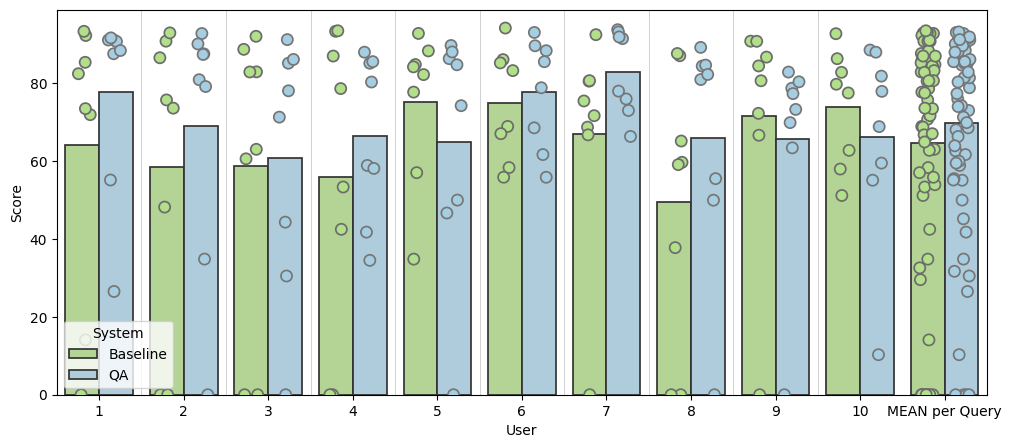

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
key = "Score"

ax = sns.barplot(x='User', y=key, data=results_with_means_users, hue='System', width=0.8,
            palette=palette, errorbar=None, alpha=1.0, linewidth=1.25, edgecolor='#333')
# make grouped stripplot
grped_bplot = sns.stripplot(x='User', 
                            y=key, 
                            hue='System',
                            jitter=0.2,
                            dodge=True, 
                            marker='o', 
                            palette=palette,
                            alpha=1.0,
                            size=8,
                            data=results_with_means_users,
                            linewidth=1.25, 
                            edgecolors='black', 
                            legend=False)
for i in range(9):
    plt.axvline(x = i + 0.5, color = 'black', linewidth = 0.5, alpha = 0.25)
print()

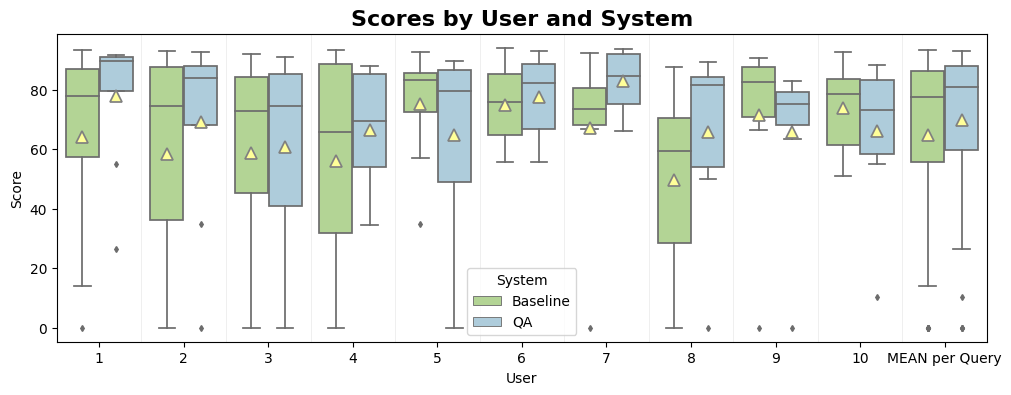

In [29]:
plt.figure(figsize=(12, 4))
ax = sns.boxplot(x='User', 
                 y=key,
                 hue='System', 
                 data=results_with_means_users, 
                 width=0.8, 
                 palette=palette, 
                 showmeans=True, 
                 meanprops={"markerfacecolor": palette[3], 
                            "markeredgecolor":"grey", 
                            "markersize":"8", 
                            "markeredgewidth": 1.25},
                 linewidth=1.25,
                 fliersize=3)
for i in range(11):
    plt.axvline(x = i + 0.5, color = 'lightgrey', linewidth = 0.5, alpha = 0.5)
plt.title('Scores by User and System', fontsize=16, fontweight='bold')
plt.savefig('user_score.png', dpi=300, bbox_inches='tight')

# Papers

In [37]:
# Read dataset distribution
import pandas as pd
dataset = pd.read_csv('dataset.csv', sep='\t')

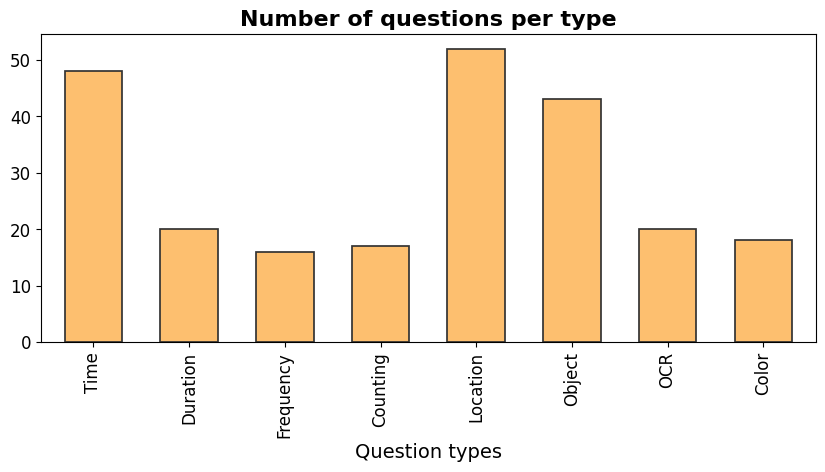

In [41]:
import matplotlib.pyplot as plt
dataset.plot(kind='bar', x='Type', y='Count', title='Number of QA pairs per type', figsize=(10, 4), legend=False, fontsize=12,
             color='#fdbf6f', alpha=1.0, linewidth=1.25, edgecolor='#333', width=0.6)
plt.title('Number of questions per type', fontsize=16, fontweight='bold')
plt.xlabel('Question types', fontsize=14)
plt.savefig('distribution.png', dpi=300, bbox_inches='tight')

In [29]:
ueq = pd.read_csv('ueq.csv', sep='\t')
ueq = ueq.melt(id_vars=['SYSTEM'], var_name='UEQ', value_name='UEQ_SCORE')

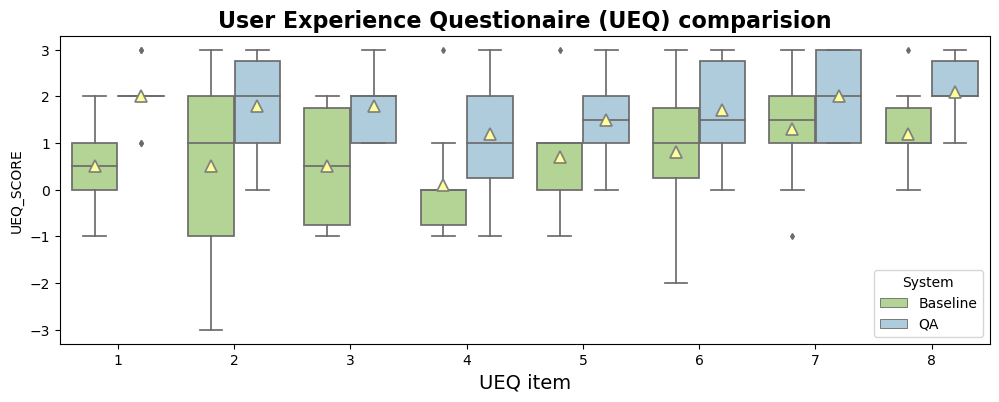

In [85]:
plt.figure(figsize=(12, 4))
import seaborn as sns
palette = ["#b2df8a", "#a6cee3", "#fdbf6f", "#ffff99"]

ax = sns.boxplot(data=ueq, 
                 hue='SYSTEM',
                 x='UEQ',
                 y='UEQ_SCORE',
                 width=0.8, 
                 palette=palette, 
                 showmeans=True, 
                 meanprops={"markerfacecolor": palette[3], 
                            "markeredgecolor":"grey", 
                            "markersize":"8", 
                            "markeredgewidth": 1.25},
                 linewidth=1.25,
                 fliersize=3)
# Move the legend to an empty part of the plot: right bottom 
ax.legend(title='System', loc='lower right', bbox_to_anchor=(1.0, 0.0), frameon=True)
# Name legend handles Baseline and QA
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Baseline', 'QA'], title='System', loc='lower right', bbox_to_anchor=(1.0, 0.0), frameon=True)

plt.title('User Experience Questionaire (UEQ) comparision', fontsize=16, fontweight='bold')
plt.xlabel('UEQ item', fontsize=14)
plt.savefig('UEQ.png', dpi=300, bbox_inches='tight')

In [34]:
ueq

,SYSTEM,UEQ,UEQ_SCORE
0,A,1,-1
1,B,1,1
2,A,1,2
3,B,1,2
4,A,1,1
...,...,...,...
155,B,8,3
156,A,8,3
157,B,8,3
158,A,8,1


In [36]:
# conduct significance test to compare the two systems
import scipy.stats as stats

# H0: The two systems have the same performance
# H1: The two systems have different performance

# We will use the Wilcoxon signed-rank test to compare the two systems
# because the data is not normally distributed
# and the two systems are dependent (i.e., the same users are using both systems)

# We will use the score as the dependent variable
# and the system as the independent variable
# and the user as the dependent variable

# Code here
field = "UEQ_SCORE"

# Do it for each users
system1_scores = ueq[
    (ueq["SYSTEM"] == "A")][field]
system2_scores = ueq[
    (ueq["SYSTEM"] == "B")][field]

# Calculate means
mean1 = np.mean(system1_scores)
mean2 = np.mean(system2_scores)
print(f"Mean of system 1 is {mean1:.2f}")
print(f"Mean of system 2 is {mean2:.2f}")

# Calculate standard deviations
std1 = np.std(system1_scores)
std2 = np.std(system2_scores)

# Calculate sample sizes
n1 = len(system1_scores)
n2 = len(system2_scores)

# Calculate the Z statistic
z = (mean1 - mean2) / np.sqrt(std1**2 / n1 + std2**2 / n2)

# Calculate the two-tailed p-value
p = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Z statistic is {z:.2f}")
print(f"P-value is {p:.10f}")

Mean of system 1 is 0.70
Mean of system 2 is 1.76
Z statistic is -5.99
P-value is 0.0000000021
